# Underfitting, Overfitting and Regularisation

We have a training set with two classes. We want a model that draws the boundary between them.

We train three models that differ only in size, look at the boundary each one draws, and read the training and validation loss curves. Then we take the worst of the three and try to repair it with L2, L1 and dropout.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.datasets import make_moons
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

In [2]:
# colours used by every plot below
BLUE = "#1C7ED6"
ORANGE = "#F76707"
GREEN = "#2F9E44"
PURPLE = "#AE3EC9"

# pale background for the boundary plots, and the two point colours
BACKGROUND = LinearSegmentedColormap.from_list("bg", ["#FFE0CC", "#FFFFFF", "#CFE8FF"])
POINTS = ListedColormap([ORANGE, BLUE])

## The data

150 points for training, 2000 points held back for validation. The model only ever computes gradients on the 150.

In [3]:
X, y = make_moons(n_samples=2150, noise=0.3, random_state=0)

Xtr, ytr = X[:150], y[:150]
Xva, yva = X[150:], y[150:]

print("training set", Xtr.shape)
print("validation set", Xva.shape)

training set (150, 2)
validation set (2000, 2)


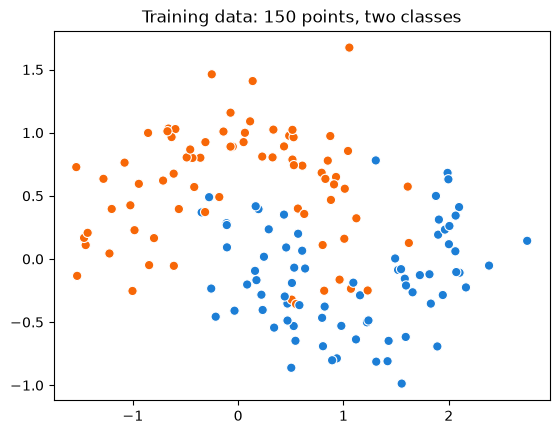

In [4]:
plt.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap=POINTS, edgecolors="white", linewidth=0.8, s=45)
plt.title("Training data: 150 points, two classes")
plt.show()

The two classes overlap. There is no boundary that separates the training points perfectly, so any model that classifies all 150 correctly has done something we do not want.

## Two helpers

One to draw the loss curves, one to draw the boundary a model has learned. The background colour is the probability the model assigns to the blue class, and the black line is where that probability is 0.5.

Each boundary is drawn twice, in two separate cells. The first shows the 150 training points the model was fitted to. The second shows 150 of the validation points the model has never seen. The boundary is the same in both, only the points change. All 2000 validation points are still used for the validation loss, the plot just draws 150 of them so it stays readable.

In [5]:
def plot_loss(history, title, ymax=1):
    plt.plot(history.history["loss"], color=BLUE, linewidth=2, label="training")
    plt.plot(history.history["val_loss"], color=ORANGE, linewidth=2, label="validation")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.ylim(0, ymax)
    plt.title(title)
    plt.legend()
    plt.show()

In [6]:
def plot_boundary(model, title, validation=False):
    xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 300), np.linspace(-2.5, 3, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid, verbose=0).reshape(xx.shape)

    if validation:
        # only the first 150 validation points are drawn, so the plot is not
        # crowded. All 2000 are still used to compute the validation loss.
        points, labels, name = Xva[:150], yva[:150], "validation points"
    else:
        points, labels, name = Xtr, ytr, "training points"

    plt.contourf(xx, yy, Z, levels=50, cmap=BACKGROUND)
    plt.contour(xx, yy, Z, levels=[0.5], colors="#212529", linewidths=2)
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap=POINTS,
                edgecolors="white", linewidth=0.8, s=45)
    plt.title(title + ", " + name)
    plt.show()

Every model below is trained the same way, so we write that once too. Full batch, 400 epochs.

In [7]:
def train(model):
    model.compile(optimizer=keras.optimizers.Adam(0.003),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model.fit(Xtr, ytr,
                     validation_data=(Xva, yva),
                     epochs=400, batch_size=150, verbose=2)

---
## Model 1: one hidden layer, 4 units (Underfitting)

In [8]:
keras.utils.set_random_seed(0)

model1 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

history1 = train(model1)

Epoch 1/400


1/1 - 0s - 184ms/step - accuracy: 0.4733 - loss: 0.7432 - val_accuracy: 0.4920 - val_loss: 0.7287


Epoch 2/400


1/1 - 0s - 34ms/step - accuracy: 0.4800 - loss: 0.7385 - val_accuracy: 0.4945 - val_loss: 0.7244


Epoch 3/400


...

1/1 - 0s - 36ms/step - accuracy: 0.8600 - loss: 0.3451 - val_accuracy: 0.8470 - val_loss: 0.3441


Epoch 399/400


1/1 - 0s - 34ms/step - accuracy: 0.8600 - loss: 0.3450 - val_accuracy: 0.8470 - val_loss: 0.3440


Epoch 400/400


1/1 - 0s - 207ms/step - accuracy: 0.8600 - loss: 0.3449 - val_accuracy: 0.8470 - val_loss: 0.3439


In [9]:
print("parameters", model1.count_params())

parameters 17


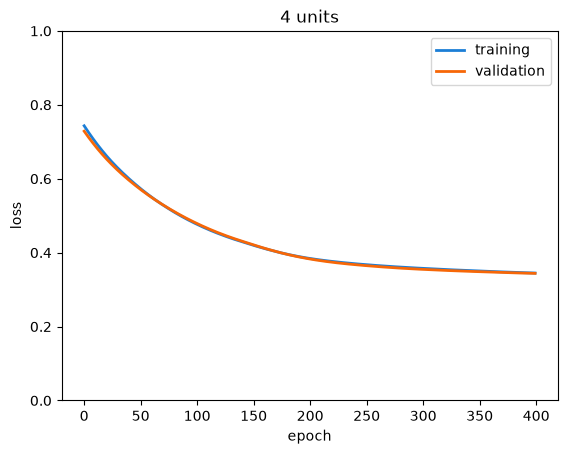

In [10]:
plot_loss(history1, "4 units")

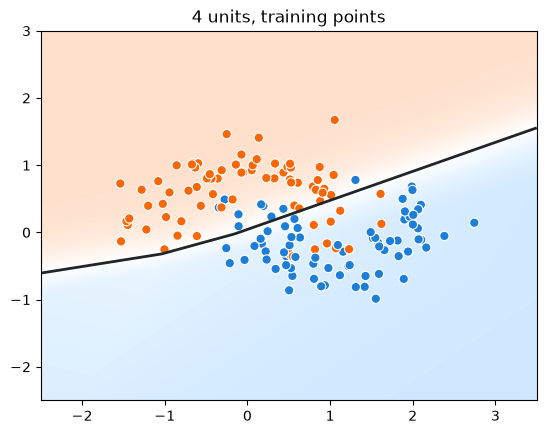

In [11]:
plot_boundary(model1, "4 units")

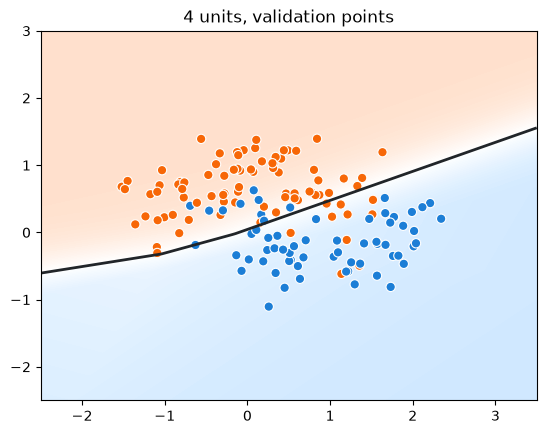

In [12]:
plot_boundary(model1, "4 units", validation=True)

---
## Model 2: four hidden layers, 256 units each (Overfitting)

In [13]:
keras.utils.set_random_seed(0)

model2 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

history2 = train(model2)

Epoch 1/400


1/1 - 0s - 493ms/step - accuracy: 0.4333 - loss: 0.6950 - val_accuracy: 0.8375 - val_loss: 0.6193


Epoch 2/400


1/1 - 0s - 41ms/step - accuracy: 0.8333 - loss: 0.6181 - val_accuracy: 0.8370 - val_loss: 0.5155


Epoch 3/400


...

1/1 - 0s - 36ms/step - accuracy: 1.0000 - loss: 1.9831e-04 - val_accuracy: 0.8775 - val_loss: 1.4711


Epoch 399/400


1/1 - 0s - 36ms/step - accuracy: 1.0000 - loss: 1.9586e-04 - val_accuracy: 0.8775 - val_loss: 1.4713


Epoch 400/400


1/1 - 0s - 36ms/step - accuracy: 1.0000 - loss: 1.9529e-04 - val_accuracy: 0.8775 - val_loss: 1.4721


In [14]:
print("parameters", model2.count_params())

parameters 198401


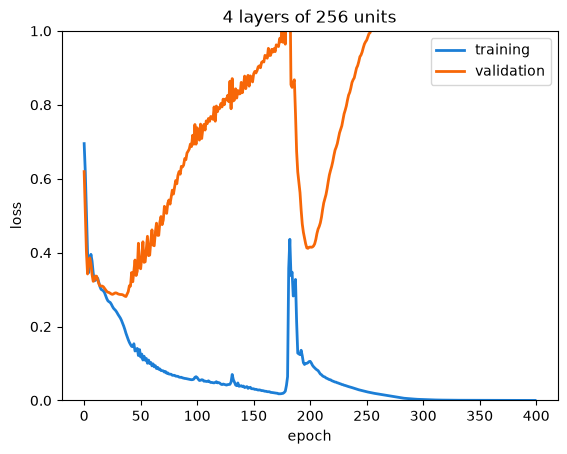

In [15]:
plot_loss(history2, "4 layers of 256 units")

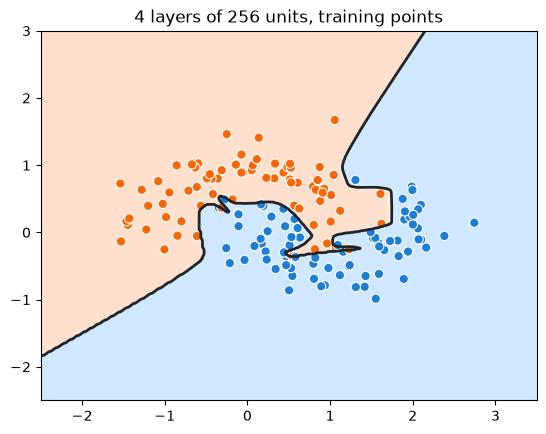

In [16]:
plot_boundary(model2, "4 layers of 256 units")

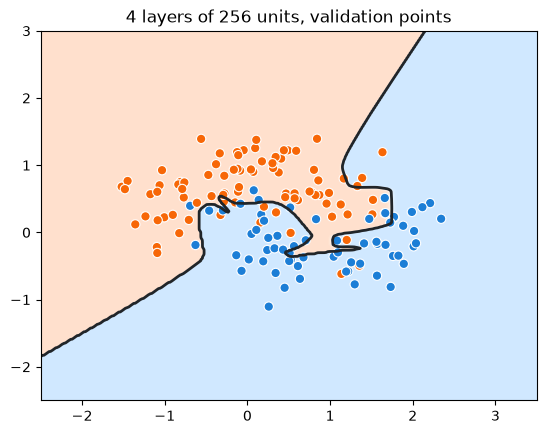

In [17]:
plot_boundary(model2, "4 layers of 256 units", validation=True)

---
## Model 3: one hidden layer, 32 units (Good Fit)

In [18]:
keras.utils.set_random_seed(0)

model3 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

history3 = train(model3)

Epoch 1/400


1/1 - 0s - 58ms/step - accuracy: 0.4933 - loss: 0.7677 - val_accuracy: 0.5045 - val_loss: 0.7523


Epoch 2/400


1/1 - 0s - 29ms/step - accuracy: 0.5000 - loss: 0.7546 - val_accuracy: 0.5180 - val_loss: 0.7399


Epoch 3/400


...

1/1 - 0s - 31ms/step - accuracy: 0.8733 - loss: 0.3122 - val_accuracy: 0.8650 - val_loss: 0.3115


Epoch 399/400


1/1 - 0s - 32ms/step - accuracy: 0.8733 - loss: 0.3121 - val_accuracy: 0.8650 - val_loss: 0.3115


Epoch 400/400


1/1 - 0s - 31ms/step - accuracy: 0.8733 - loss: 0.3120 - val_accuracy: 0.8650 - val_loss: 0.3115


In [19]:
print("parameters", model3.count_params())

parameters 129


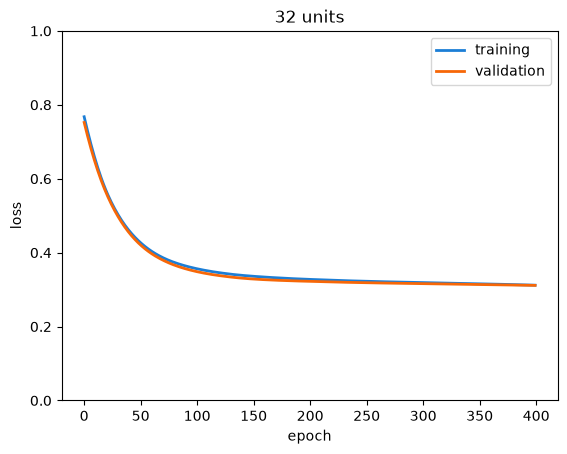

In [20]:
plot_loss(history3, "32 units")

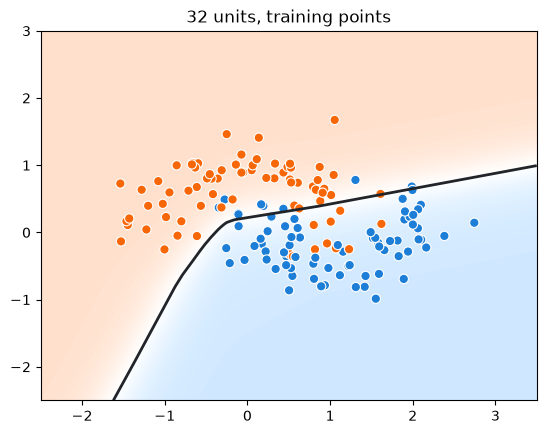

In [21]:
plot_boundary(model3, "32 units")

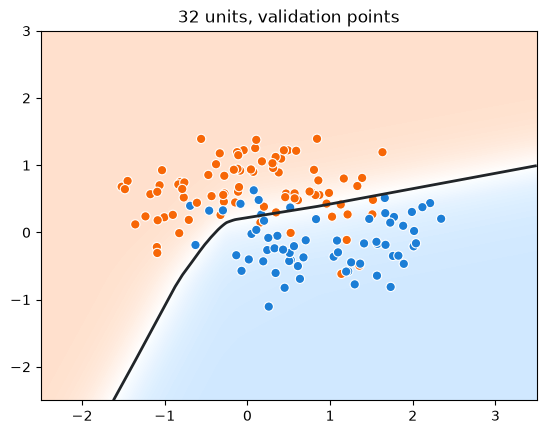

In [22]:
plot_boundary(model3, "32 units", validation=True)

---
## Regularisation Techniques (L1, L2, Dropout, Early Stopping)

In [23]:
# L1 and L2 Regularisation -> Reduce the weights with huge magnitude
# Dropout Regularisation -> Randomly turns off some neurons
# Early Stopping -> Stops the training midway if it feels it is going for overfit

In [24]:
def train_long(model):
    model.compile(optimizer=keras.optimizers.Adam(0.003),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model.fit(Xtr, ytr,
                     validation_data=(Xva, yva),
                     epochs=600, batch_size=150, verbose=2)

---
## Model 4: 3 x 512 units, no regularisation (Overfitting Baseline)

In [25]:
keras.utils.set_random_seed(0)

model4 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

history4 = train_long(model4)

Epoch 1/600


1/1 - 0s - 351ms/step - accuracy: 0.4933 - loss: 0.6904 - val_accuracy: 0.7955 - val_loss: 0.5444


Epoch 2/600


1/1 - 0s - 37ms/step - accuracy: 0.8000 - loss: 0.5431 - val_accuracy: 0.8235 - val_loss: 0.4073


Epoch 3/600


...

1/1 - 0s - 37ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8825 - val_loss: 1.2939


Epoch 599/600


1/1 - 0s - 36ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8825 - val_loss: 1.2959


Epoch 600/600


1/1 - 0s - 36ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8825 - val_loss: 1.2973


In [26]:
print("parameters", model4.count_params())

parameters 527361


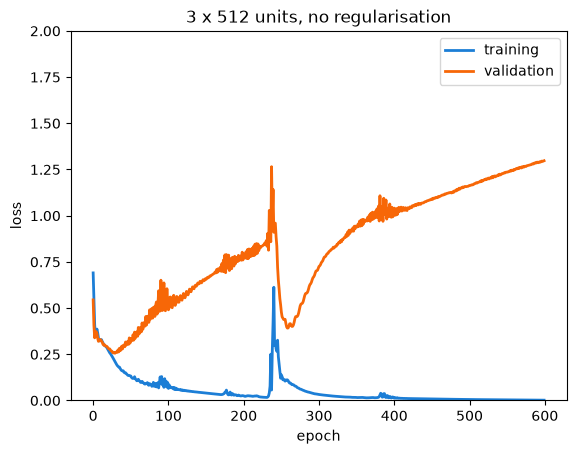

In [27]:
plot_loss(history4, "3 x 512 units, no regularisation", ymax=2)

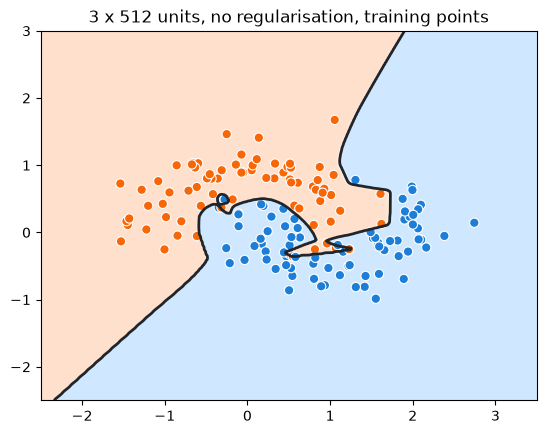

In [28]:
plot_boundary(model4, "3 x 512 units, no regularisation")

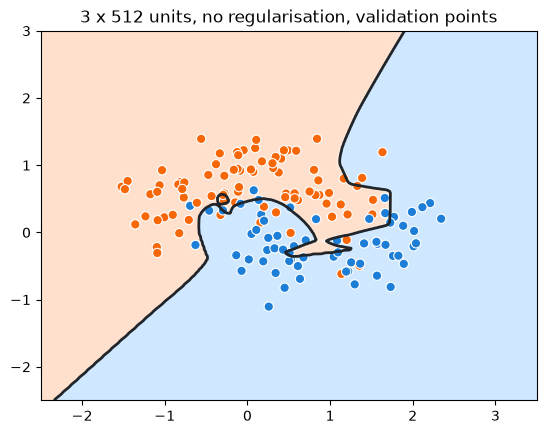

In [29]:
plot_boundary(model4, "3 x 512 units, no regularisation", validation=True)

---
## Model 5: 3 x 512 units with L2 Regularisation

In [30]:
keras.utils.set_random_seed(0)

model_l2 = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dense(512, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.Dense(1, activation="sigmoid"),
])

history_l2 = train_long(model_l2)

Epoch 1/600


1/1 - 0s - 106ms/step - accuracy: 0.4933 - loss: 0.7932 - val_accuracy: 0.7955 - val_loss: 0.6453


Epoch 2/600


1/1 - 0s - 46ms/step - accuracy: 0.7933 - loss: 0.6441 - val_accuracy: 0.8225 - val_loss: 0.5067


Epoch 3/600


...

1/1 - 0s - 51ms/step - accuracy: 0.9867 - loss: 0.0552 - val_accuracy: 0.8800 - val_loss: 0.7738


Epoch 599/600


1/1 - 0s - 50ms/step - accuracy: 0.9933 - loss: 0.0496 - val_accuracy: 0.8805 - val_loss: 0.7786


Epoch 600/600


1/1 - 0s - 51ms/step - accuracy: 0.9867 - loss: 0.0573 - val_accuracy: 0.8805 - val_loss: 0.7608


In [31]:
print("parameters", model_l2.count_params())

parameters 527361


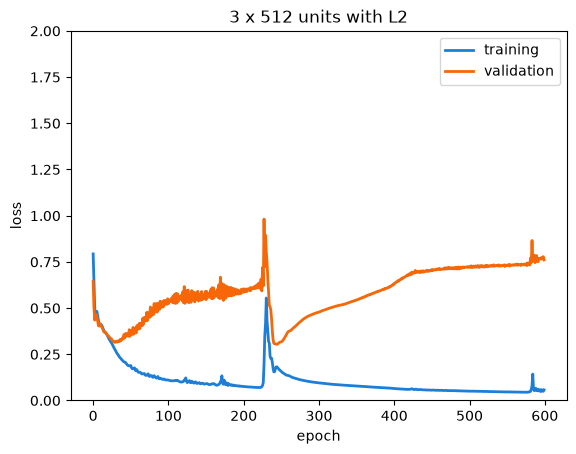

In [32]:
plot_loss(history_l2, "3 x 512 units with L2", ymax=2)

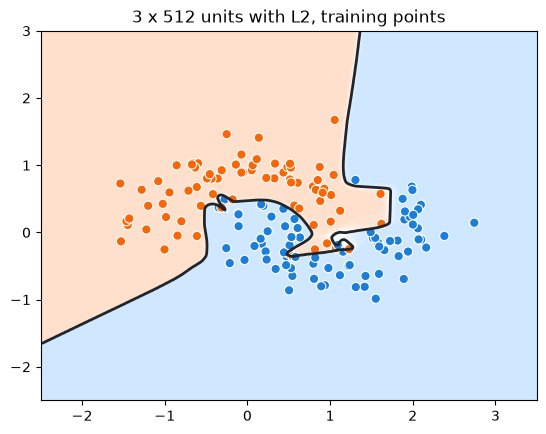

In [33]:
plot_boundary(model_l2, "3 x 512 units with L2")

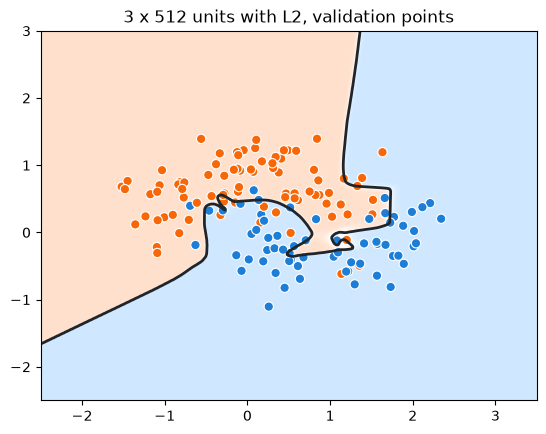

In [34]:
plot_boundary(model_l2, "3 x 512 units with L2", validation=True)

---
## Model 6: 3 x 512 units with Dropout

In [35]:
keras.utils.set_random_seed(0)

model_do = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dropout(0.7),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dropout(0.7),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dropout(0.7),
    keras.layers.Dense(1, activation="sigmoid"),
])

history_do = train_long(model_do)

Epoch 1/600


1/1 - 0s - 221ms/step - accuracy: 0.4800 - loss: 0.7105 - val_accuracy: 0.8095 - val_loss: 0.6309


Epoch 2/600


1/1 - 0s - 44ms/step - accuracy: 0.7133 - loss: 0.6316 - val_accuracy: 0.8025 - val_loss: 0.5538


Epoch 3/600


...

1/1 - 0s - 43ms/step - accuracy: 0.9267 - loss: 0.1283 - val_accuracy: 0.8965 - val_loss: 0.4103


Epoch 599/600


1/1 - 0s - 41ms/step - accuracy: 0.9533 - loss: 0.1201 - val_accuracy: 0.8965 - val_loss: 0.4091


Epoch 600/600


1/1 - 0s - 41ms/step - accuracy: 0.9533 - loss: 0.1121 - val_accuracy: 0.8985 - val_loss: 0.4092


In [36]:
print("parameters", model_do.count_params())

parameters 527361


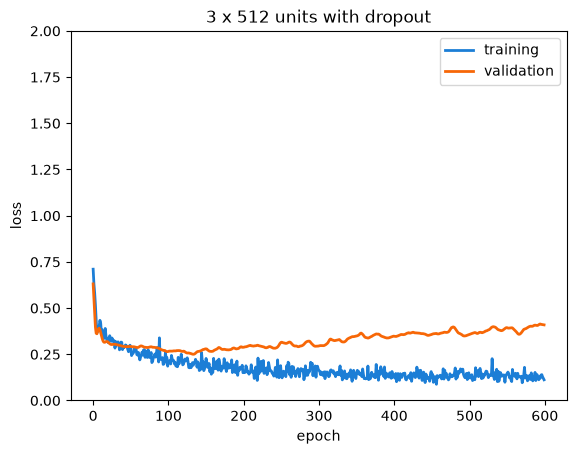

In [37]:
plot_loss(history_do, "3 x 512 units with dropout", ymax=2)

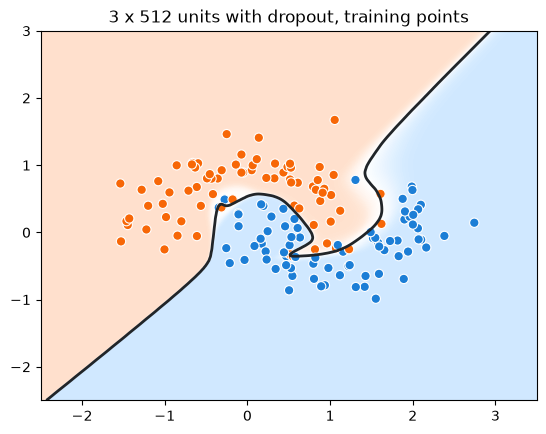

In [38]:
plot_boundary(model_do, "3 x 512 units with dropout")

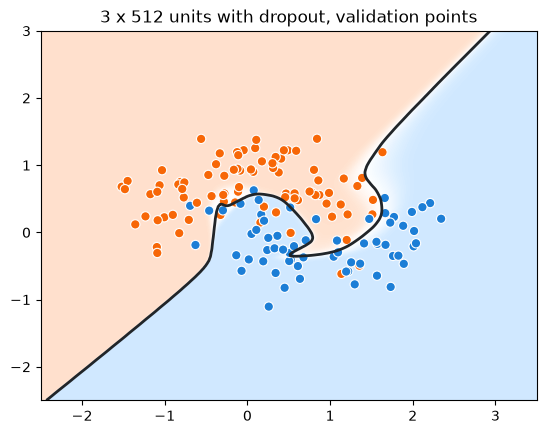

In [39]:
plot_boundary(model_do, "3 x 512 units with dropout", validation=True)